In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
df = pd.read_csv(r"D:\Private\Fiv\Stock-Price-Prediction\Datasets\combined_tech_data.csv")
COMPANY="general"
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,company_name,ticker
0,2018-01-18 00:00:00-05:00,42.196978,42.368714,41.933498,42.171101,124773600,0.0,0.0,APPLE,AAPL
1,2018-01-19 00:00:00-05:00,42.018193,42.246386,41.735892,41.982906,129700400,0.0,0.0,APPLE,AAPL
2,2018-01-22 00:00:00-05:00,41.710007,41.822927,41.545332,41.639431,108434400,0.0,0.0,APPLE,AAPL
3,2018-01-23 00:00:00-05:00,41.710009,42.213446,41.597090,41.648842,130756400,0.0,0.0,APPLE,AAPL
4,2018-01-24 00:00:00-05:00,41.698250,41.710013,40.745482,40.985439,204420400,0.0,0.0,APPLE,AAPL


In [3]:
df.drop(['Dividends','Stock Splits','company_name','ticker'], axis=1, inplace=True)

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2018-01-18 00:00:00-05:00,42.196978,42.368714,41.933498,42.171101,124773600
1,2018-01-19 00:00:00-05:00,42.018193,42.246386,41.735892,41.982906,129700400
2,2018-01-22 00:00:00-05:00,41.710007,41.822927,41.545332,41.639431,108434400
3,2018-01-23 00:00:00-05:00,41.710009,42.213446,41.597090,41.648842,130756400
4,2018-01-24 00:00:00-05:00,41.698250,41.710013,40.745482,40.985439,204420400


In [5]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [6]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    7044 non-null   object 
 1   Open    7044 non-null   float64
 2   High    7044 non-null   float64
 3   Low     7044 non-null   float64
 4   Close   7044 non-null   float64
 5   Volume  7044 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 330.3+ KB


In [8]:
df.describe()

,Open,High,Low,Close,Volume
count,7044.000000,7044.000000,7044.000000,7044.000000,7.044000e+03
mean,148.935636,150.516169,147.322947,148.975062,5.945712e+07
std,86.130671,86.819847,85.359250,86.124081,4.625625e+07
min,34.379957,34.795441,33.907168,33.952538,7.164500e+06
25%,89.020587,89.837484,87.877499,88.871876,2.728070e+07
50%,132.898234,133.908791,131.324559,132.817268,4.469875e+07
75%,177.358006,178.977501,175.523792,177.284142,7.638525e+07
max,465.228569,466.573450,462.698189,465.786438,4.265100e+08


In [9]:
def detect_and_handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_below = df[column] < lower_bound
    outliers_above = df[column] > upper_bound
    total_outliers = outliers_below.sum() + outliers_above.sum()
    
    print(f"Column '{column}': Outliers detected - {total_outliers}")
    
    if total_outliers > 0:
        df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else x)
        df[column] = df[column].apply(lambda x: upper_bound if x > upper_bound else x)
columns_to_check = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in columns_to_check:
    detect_and_handle_outliers(df, col)
print(df.describe())


Column 'Open': Outliers detected - 467
Column 'High': Outliers detected - 468
Column 'Low': Outliers detected - 468
Column 'Close': Outliers detected - 467
Column 'Volume': Outliers detected - 341
              Open         High          Low        Close        Volume
count  7044.000000  7044.000000  7044.000000  7044.000000  7.044000e+03
mean    144.143423   145.704314   142.571049   144.189773  5.693372e+07
std      73.272195    73.933950    72.589127    73.287834  3.744799e+07
min      34.379957    34.795441    33.907168    33.952538  7.164500e+06
25%      89.020587    89.837484    87.877499    88.871876  2.728070e+07
50%     132.898234   133.908791   131.324559   132.817268  4.469875e+07
75%     177.358006   178.977501   175.523792   177.284142  7.638525e+07
max     309.864133   312.687526   306.993233   309.902540  1.500421e+08


In [10]:
def create_scatter_plot(x_data, y_data, size_data=None, title=None, x_label=None, y_label=None, figsize=(15,7)):
    plt.figure(figsize=figsize)
    sns.scatterplot(x=x_data, y=y_data, size=size_data)
    if title:
        plt.title(title)
    if x_label:
        plt.xlabel(x_label)
    if y_label:
        plt.ylabel(y_label)
    plt.show()
def create_line_plot(x_data, y_data, title=None, x_label=None, y_label=None, figsize=(15,7)):
    plt.figure(figsize=figsize)
    sns.lineplot(x=x_data, y=y_data)
    if title:
        plt.title(title)
    if x_label:
        plt.xlabel(x_label)
    if y_label:
        plt.ylabel(y_label)
    plt.show()

C:\Users\hmajeed\AppData\Local\Temp\ipykernel_80900\2014392620.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


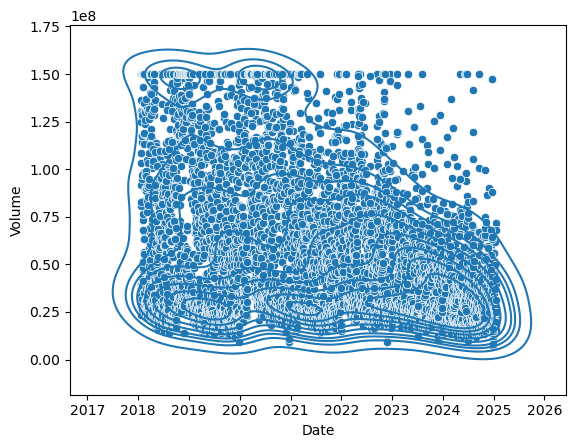

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
sns.scatterplot(x = df['Date'], y = df['Volume'])
sns.kdeplot(x = df['Date'], y = df['Volume'])
plt.show()

C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


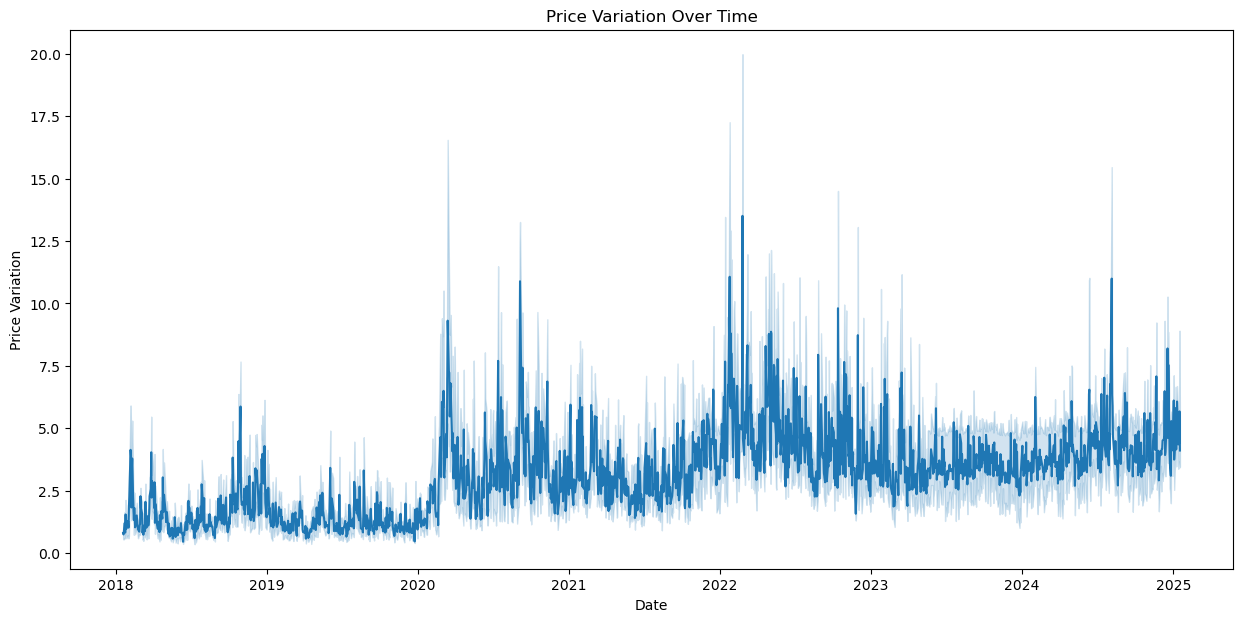

In [12]:
create_line_plot(df['Date'], df['High'] - df['Low'],
                 title='Price Variation Over Time', x_label='Date', y_label='Price Variation')

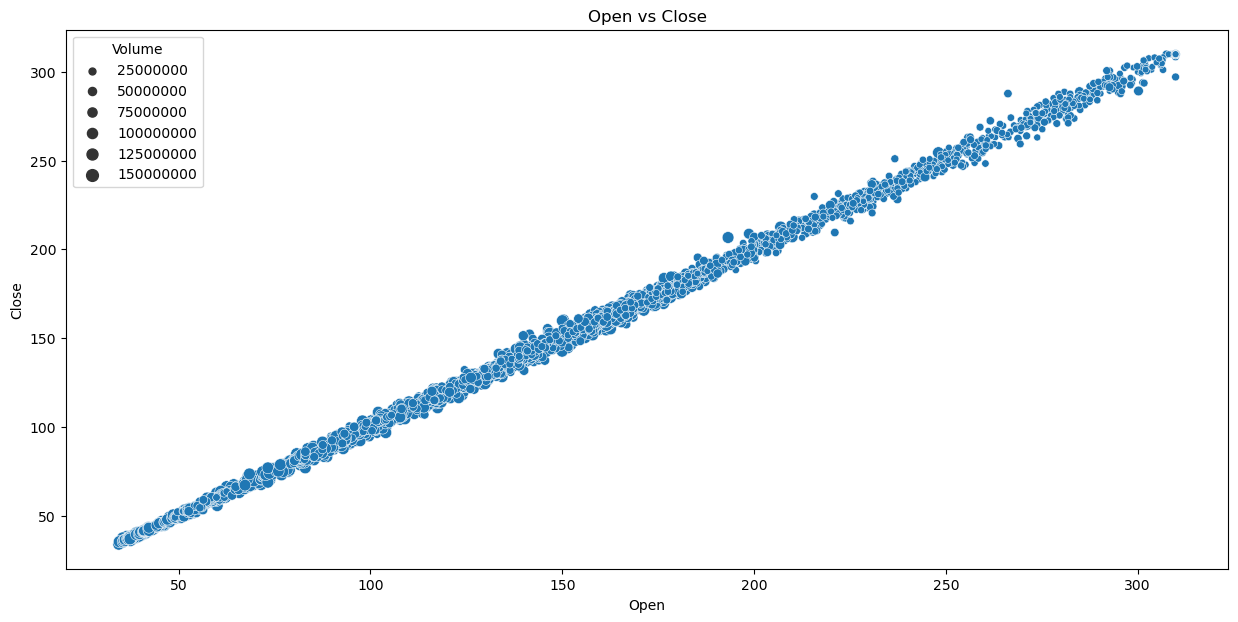

In [13]:
create_scatter_plot(df['Open'], df['Close'], size_data=df['Volume'],
                    title='Open vs Close', x_label='Open', y_label='Close')

C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


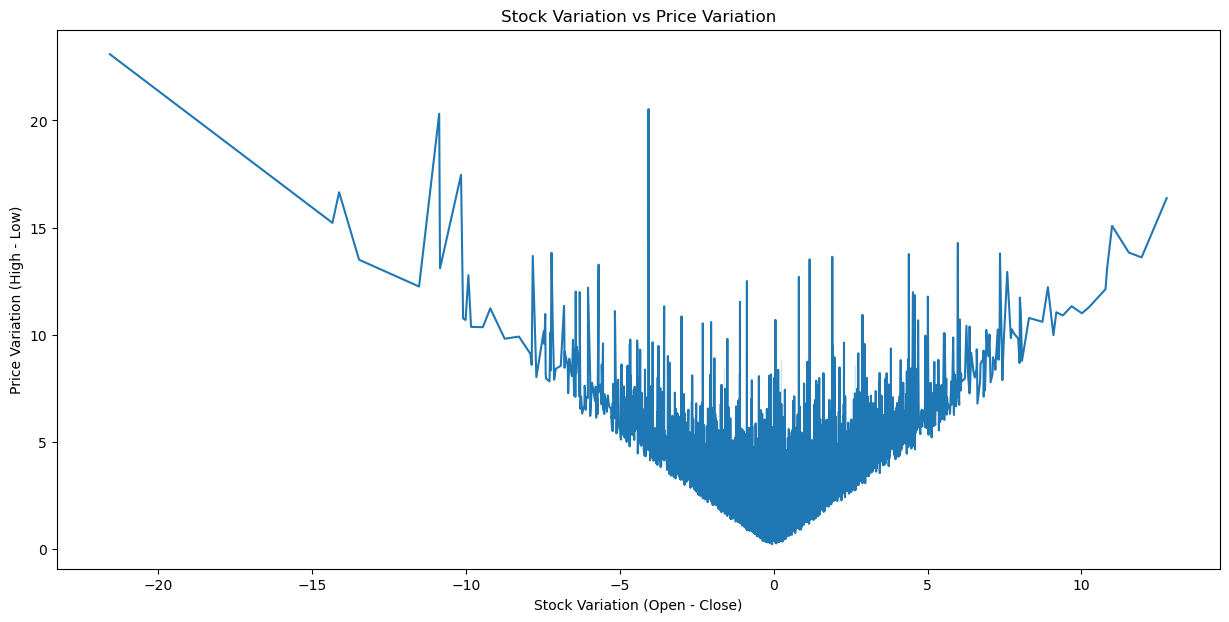

In [14]:
create_line_plot(df['Open'] - df['Close'], df['High'] - df['Low'],
                 title='Stock Variation vs Price Variation',
                 x_label='Stock Variation (Open - Close)',
                 y_label='Price Variation (High - Low)')

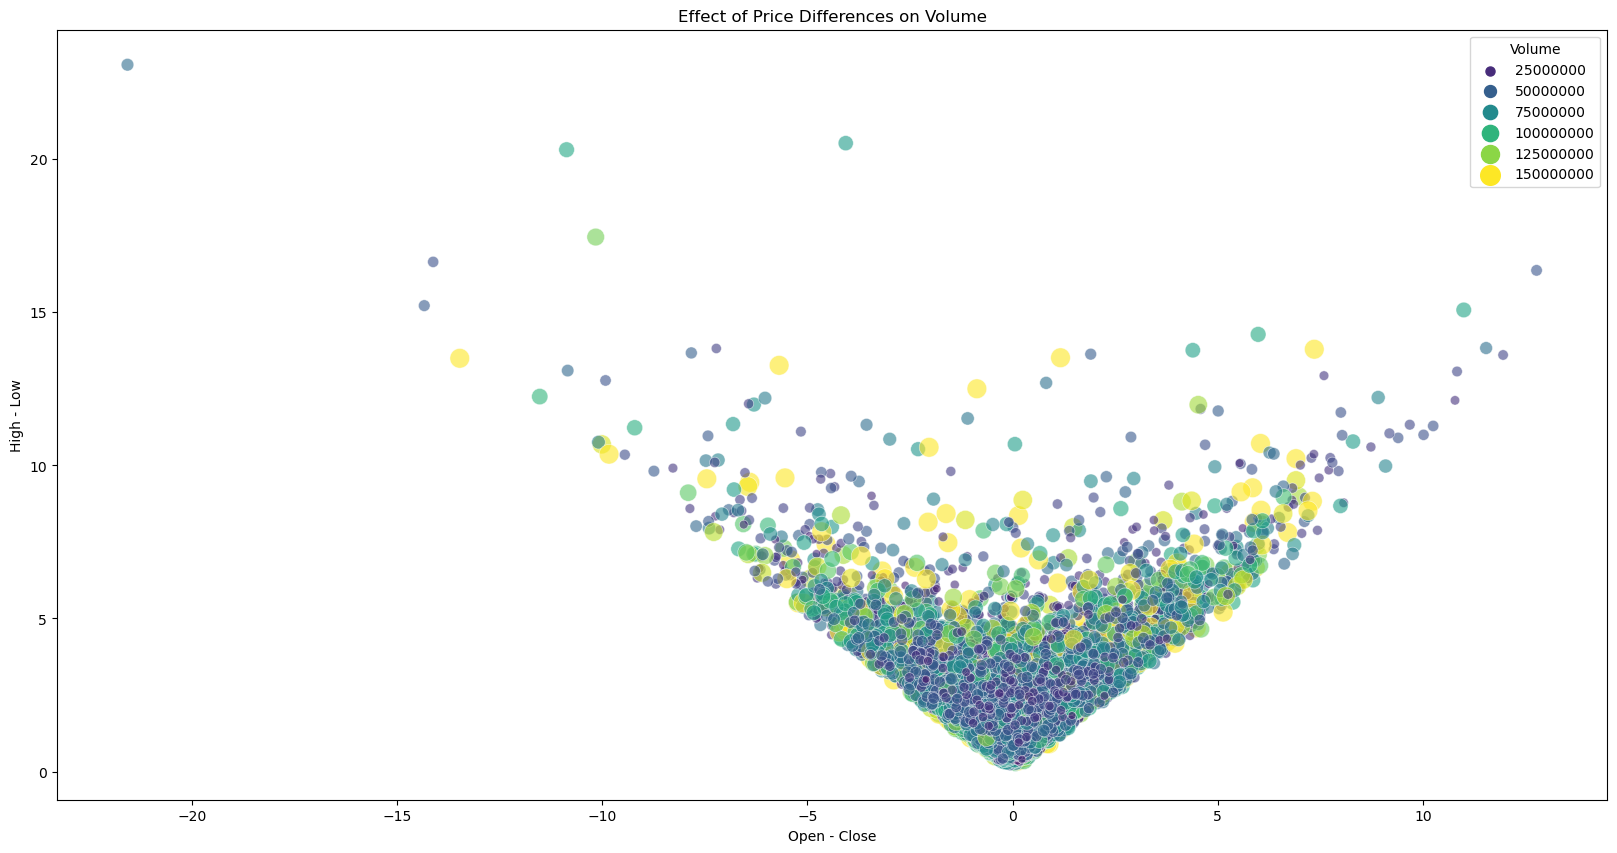

In [15]:
plt.figure(figsize = (20,10))
sns.scatterplot(x=df['Open'] - df['Close'], y=df['High'] - df['Low'], hue=df['Volume'], palette='viridis', size=df['Volume'], sizes=(20, 200), alpha=0.6)
plt.title('Effect of Price Differences on Volume')
plt.xlabel('Open - Close')
plt.ylabel('High - Low')
plt.show()

C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hmajeed\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

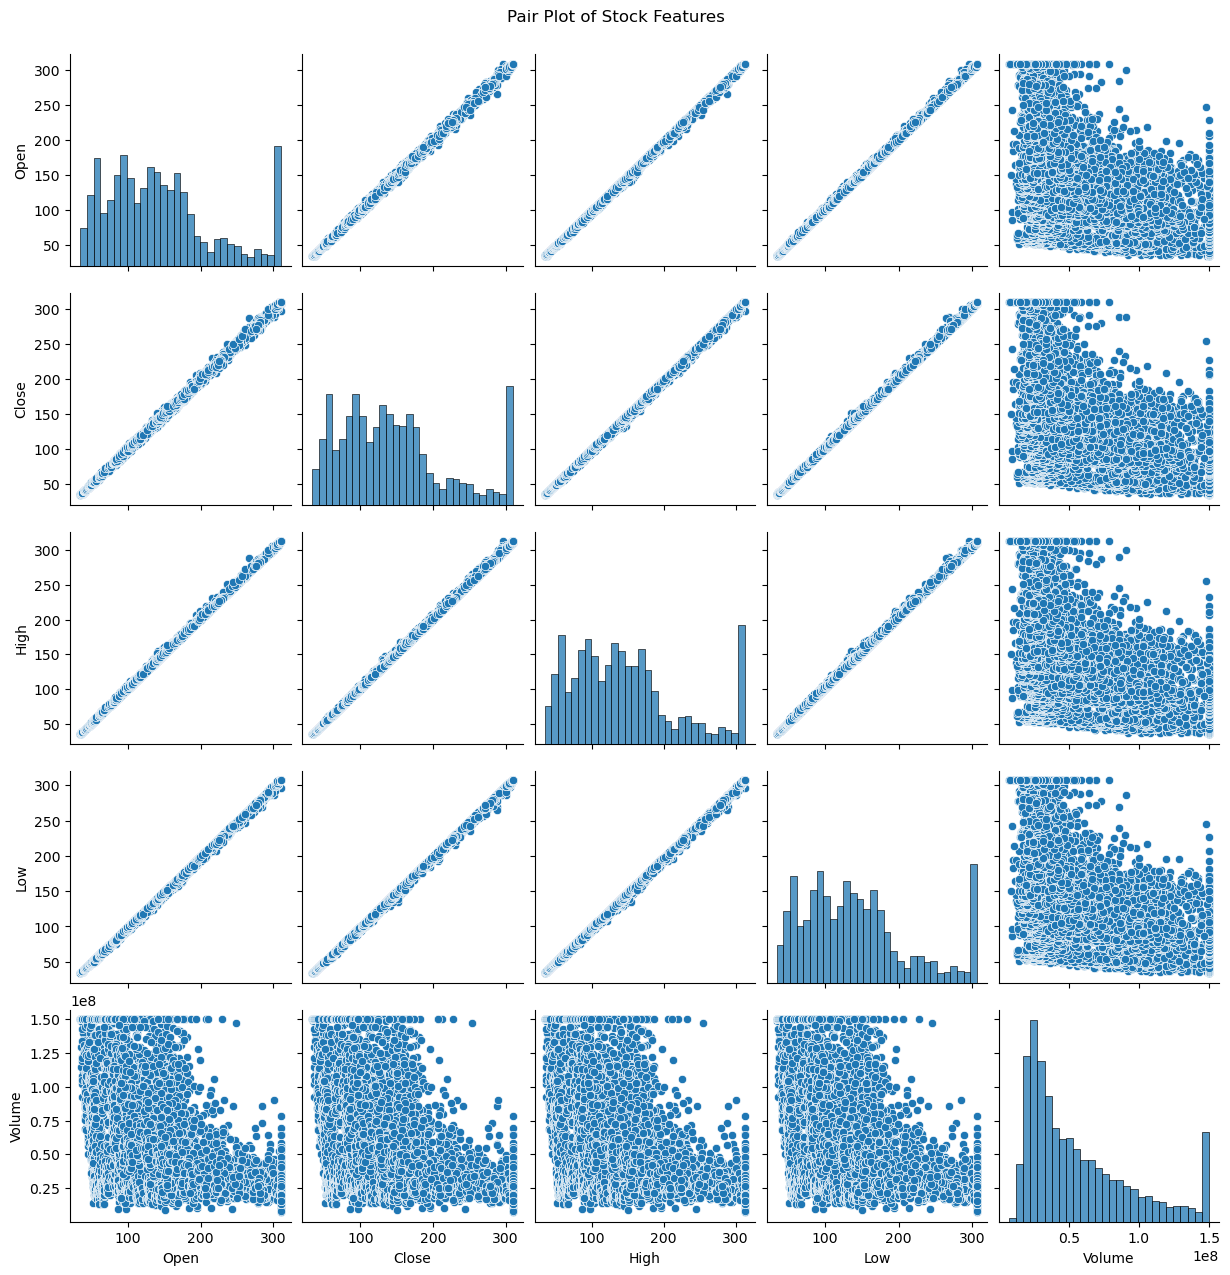

In [16]:
subset = df[['Open', 'Close', 'High', 'Low', 'Volume']]
sns.pairplot(subset)
plt.suptitle('Pair Plot of Stock Features', y=1.02)
plt.show()

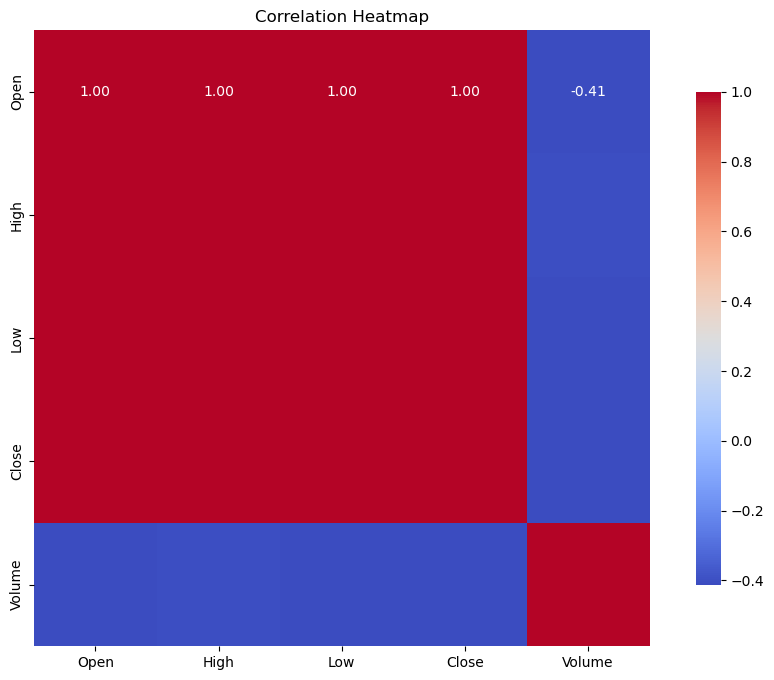

In [17]:
correlation_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.show()
plt.show()

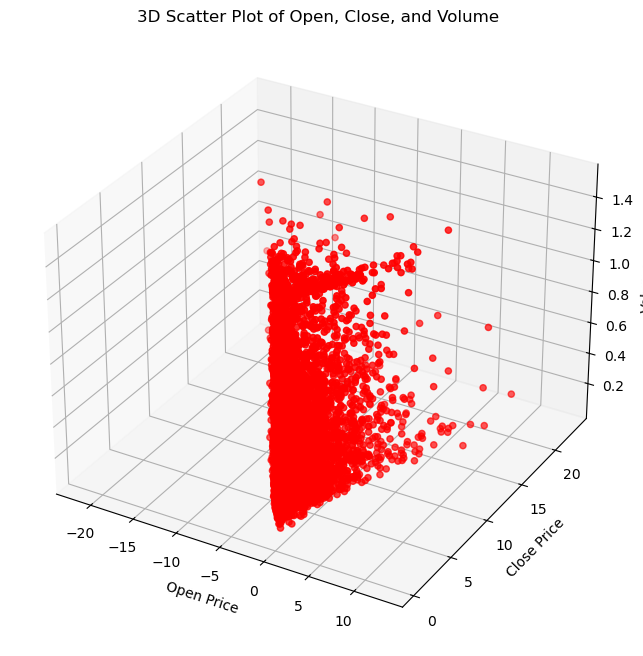

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Open']- df['Close'], df['High'] - df['Low'],df['Volume'], c='r', marker='o')
ax.set_xlabel('Open Price')
ax.set_ylabel('Close Price')
ax.set_zlabel('Volume')
plt.title('3D Scatter Plot of Open, Close, and Volume')
plt.show()

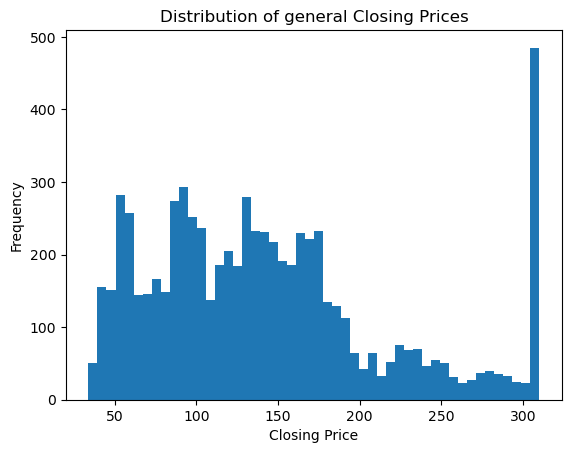

In [19]:
plt.hist(df['Close'], bins=50)
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.title(f'Distribution of {COMPANY} Closing Prices')
plt.show()

In [20]:
df.drop(['Date'], axis=1, inplace=True)

In [21]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close'].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)
X_test_scaled = X_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

In [23]:
def evaluate_model(model, X_test_scaled, y_test, y_scaler):
    predictions_scaled = model.predict(X_test_scaled)
    predictions = y_scaler.inverse_transform(predictions_scaled.reshape(-1, 1))
    y_true = y_test
    
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    mae = mean_absolute_error(y_true, predictions)
    mape = mean_absolute_percentage_error(y_true, predictions)
    
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}\n")
    return rmse, mae, mape

model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)
rmse, mae, mape = evaluate_model(model, X_test_scaled, y_test, y_scaler)

RMSE: 0.9087064874762393
MAE: 0.6142649039580178
MAPE: 0.00480974554395323



In [24]:
X_scaler_filename = f"{COMPANY}_X_scaler.pkl"
y_scaler_filename = f"{COMPANY}_y_scaler.pkl"
model_filename = f"{COMPANY}_model.pkl"
joblib.dump(X_scaler, X_scaler_filename)
joblib.dump(y_scaler, y_scaler_filename)
joblib.dump(model, model_filename)
print(f"Model and scalers saved as {model_filename}, {X_scaler_filename}, and {y_scaler_filename}")

Model and scalers saved as general_model.pkl, general_X_scaler.pkl, and general_y_scaler.pkl


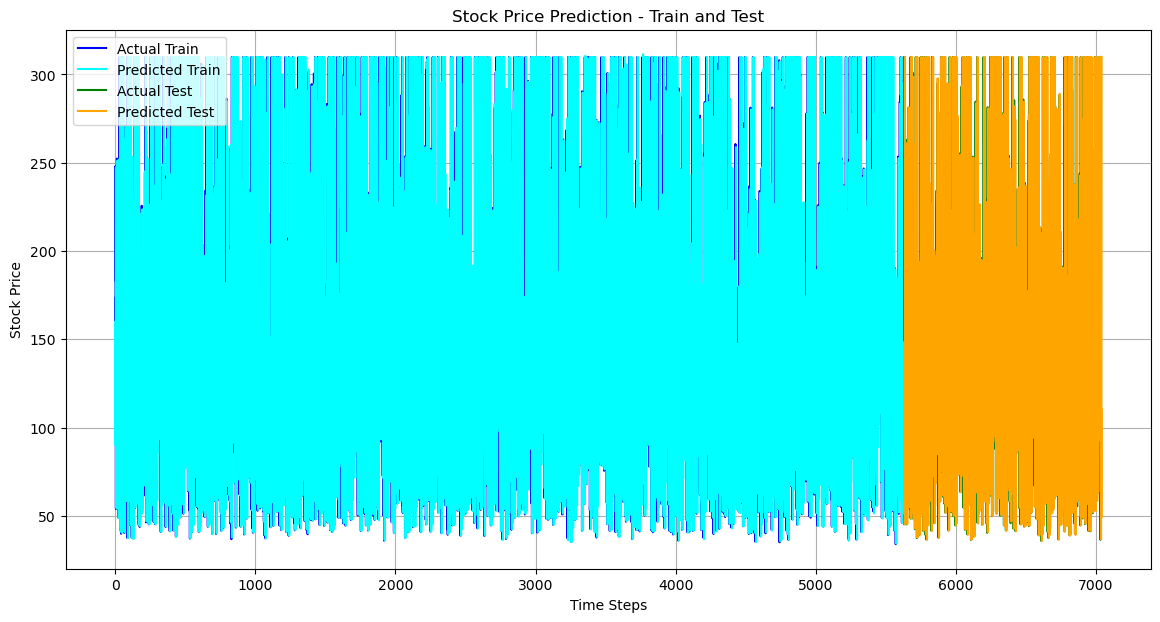


Validation Statistics:
Training Data - Mean Actual: 144.50, Mean Predicted: 144.49
Test Data - Mean Actual: 143.08, Mean Predicted: 142.96


In [25]:
n_steps = 5
train_predictions_scaled = model.predict(X_train_scaled)
test_predictions_scaled = model.predict(X_test_scaled)
train_predictions = y_scaler.inverse_transform(train_predictions_scaled.reshape(-1, 1))
test_predictions = y_scaler.inverse_transform(test_predictions_scaled.reshape(-1, 1))
y_train_actual = np.array(y_train[n_steps-1:]).reshape(-1, 1)
y_test_actual = np.array(y_test[n_steps-1:]).reshape(-1, 1)
plt.figure(figsize=(14, 7))
plt.plot(range(len(y_train_actual)), y_train_actual, label="Actual Train", color="blue")
plt.plot(range(len(train_predictions)), train_predictions, label="Predicted Train", color="cyan")
test_index_start = len(y_train_actual)
plt.plot(range(test_index_start, test_index_start + len(y_test_actual)), 
         y_test_actual, label="Actual Test", color="green")
plt.plot(range(test_index_start, test_index_start + len(test_predictions)), 
         test_predictions, label="Predicted Test", color="orange")
plt.title("Stock Price Prediction - Train and Test")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)  
plt.show()
print("\nValidation Statistics:")
print(f"Training Data - Mean Actual: {np.mean(y_train_actual):.2f}, Mean Predicted: {np.mean(train_predictions):.2f}")
print(f"Test Data - Mean Actual: {np.mean(y_test_actual):.2f}, Mean Predicted: {np.mean(test_predictions):.2f}")

In [26]:
model_name = f"{COMPANY}_model.pkl"
X_scaler_name = f"{COMPANY}_X_scaler.pkl"
y_scaler_name = f"{COMPANY}_y_scaler.pkl"
model = joblib.load(model_name)
X_scaler = joblib.load(X_scaler_name)
y_scaler = joblib.load(y_scaler_name)
new_data = df[['Open', 'High', 'Low', 'Volume']].iloc[[0]]
new_data_scaled = X_scaler.transform(new_data)
predictions_scaled = model.predict(new_data_scaled)
predictions = y_scaler.inverse_transform(predictions_scaled.reshape(-1, 1))
print("\nValidation Information:")
print("Input data shape:", new_data.shape)
print("Scaled input shape:", new_data_scaled.shape)
print("Raw scaled prediction:", predictions_scaled[0])
print("Final prediction:", predictions[0][0])


Validation Information:
Input data shape: (1, 4)
Scaled input shape: (1, 4)
Raw scaled prediction: [0.02969469]
Final prediction: 42.1467877467245
